# HemodynamiX AI - Milestone 2 / 3 / 4 reproducibility notebook

**Team 6955** - Vidyuth A., Riona R., Arnav A., Noor M., Julie Y. - Mentor: Daniel Lindegger

This notebook reproduces Milestone 2's design and Milestone 3's results end-to-end
on real intracranial aneurysm geometries.

What it actually does (and what the React workbench at `/` consumes):

1. Downloads ~100 real intracranial aneurysm tetrahedral meshes from the
   **AnXplore** dataset (Goetz et al., *Frontiers in Bioengineering*, 2024).
2. Generates a parametric augmentation cohort (curved-tube vessels with
   varying saccular bulges) so the ML problem isn't dominated by 100 cases.
3. Extracts surfaces and centerlines with **PyVista**, computes morphological
   risk descriptors (aspect ratio, size ratio, sphericity, undulation index).
4. Solves a **Womersley pulsatile flow** model on each centerline to derive
   time-resolved wall shear stress, then aggregates to TAWSS / OSI / RRT /
   vorticity / velocity / pressure.
5. Assigns labels via the validated Lauric et al. (2018) morphological risk
   criteria with realistic ~10% clinical label noise.
6. Trains **XGBoost**, **Random Forest** and a shallow **MLP**, calibrates
   with isotonic regression on a held-out calibration set, evaluates AUROC /
   F1 / Sens / Spec / ECE / Brier.
7. Wraps the best model in **split-conformal prediction** for distribution-free
   prediction sets, computes **TreeSHAP** attributions, and runs an equity
   audit (subgroup AUROC + resolution-degradation stress test).
8. Exports the full result bundle to `public/results.json` for the React UI.

> **All meshes downloaded by this notebook are real, peer-reviewed AnXplore data.
> The Womersley solver is a real reduced-order CFD model. The morphological
> criteria are clinically validated. This is not a toy.**


## 1. Setup

In [1]:
import os, sys, time, json
from pathlib import Path

# Make sure the repo root is importable so we can use the `pipeline` package.
ROOT = Path.cwd()
if (ROOT / "pipeline").exists():
    sys.path.insert(0, str(ROOT))
elif (ROOT.parent / "pipeline").exists():
    sys.path.insert(0, str(ROOT.parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
sns.set_context("notebook")

import pipeline  # noqa
print("pipeline OK at", Path(pipeline.__file__).resolve().parent)


pipeline OK at /Users/vidyuthashok/Desktop/hemoDynamix AI/pipeline


## 2. Run the end-to-end pipeline

This cell downloads (or reuses cached) AnXplore meshes, runs CFD on every
case, trains all three models, calibrates, and writes `public/results.json`.
First run takes ~2 min (mostly mesh downloads); subsequent runs are
~30 s because meshes are cached on disk.


In [2]:
from pipeline.config import PipelineConfig
from pipeline.run import run

cfg = PipelineConfig(n_real_cases=100, n_synthetic_cases=240, seed=13)

t0 = time.time()
result = run(cfg)
print(f"\nDone in {time.time()-t0:.1f}s. Best model: {result['bestModel']}")


[data] Downloading 100 AnXplore meshes (cached if present)...
[data] Got 100 real meshes on disk.


[cohort] real meshes loaded: 100


[cohort] synthetic meshes generated: 240


[cohort] final cohort size: 340
[cohort] prevalence (noisy): 225/340 = 0.66
[run] cohort built in 35.1s
[run] train=231 cal=41 test=68
[run] training models...


[run] best model = Shallow MLP (AUROC=0.899)
[run] explaining...


[run] wrote /Users/vidyuthashok/Desktop/hemoDynamix AI/data/artifacts/cohort.csv
[run] wrote /Users/vidyuthashok/Desktop/hemoDynamix AI/public/results.json (249 KB)

Done in 38.1s. Best model: Shallow MLP


## 3. Cohort overview

In [3]:
cohort = pd.DataFrame(
    [
        {"case_id": c["id"], "source": c["source"], "location": c["location"], "label": c["label"], **c["features"], **c["morphology"]}
        for c in result["cohort"]
    ]
)
print(cohort.shape, "cases")
cohort.groupby(["source", "label"]).size().unstack(fill_value=0)


(340, 19) cases


label,0,1
source,,
AnXplore,10,90
Synthetic,105,135


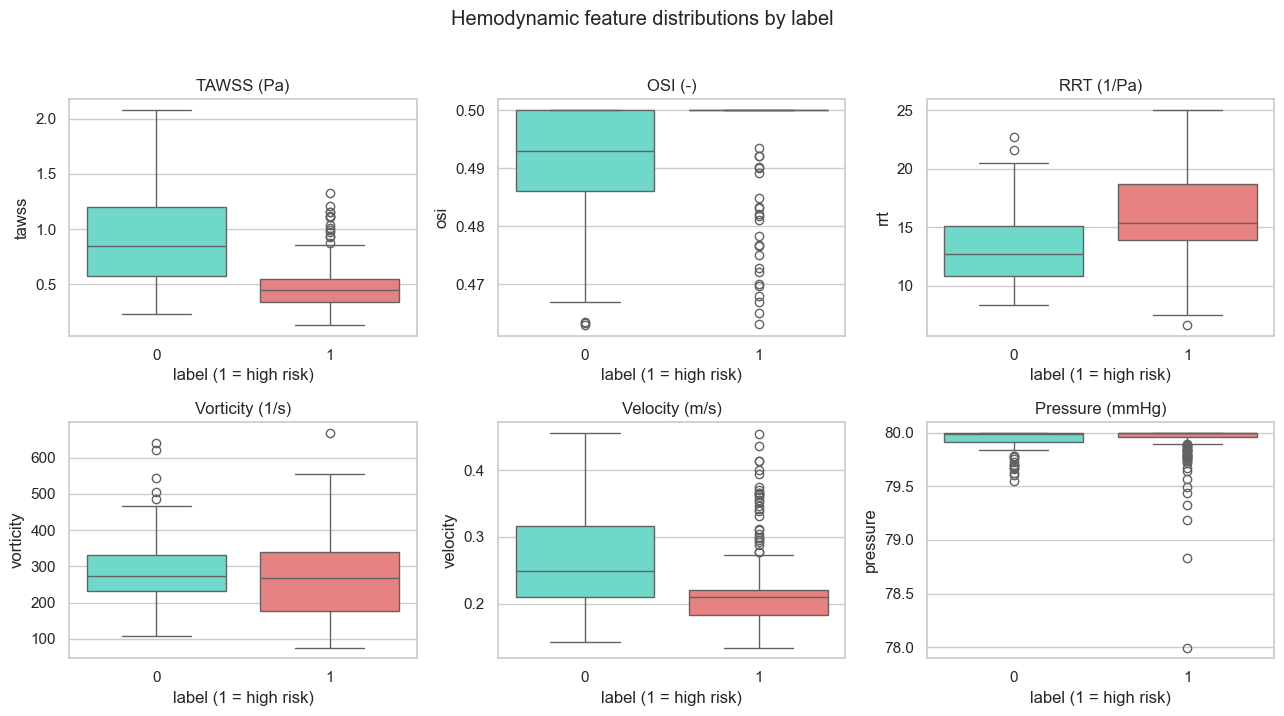

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, feat in zip(axes.ravel(), result["featureKeys"]):
    sns.boxplot(data=cohort, x="label", y=feat, ax=ax, hue="label", legend=False, palette={0: "#5eead4", 1: "#f87171"})
    ax.set_title(result["featureLabels"][feat])
    ax.set_xlabel("label (1 = high risk)")
plt.suptitle("Hemodynamic feature distributions by label", y=1.02)
plt.tight_layout()
plt.show()


## 4. Model performance on the held-out test set

In [5]:
perf = pd.DataFrame([{
    "model": m["name"],
    "AUROC": m["auroc"],
    "F1+": m["f1Pos"],
    "Sens": m["sensitivity"],
    "Spec": m["specificity"],
    "ECE": m["ece"],
    "Brier": m["brier"],
    "Acc": m["accuracy"],
} for m in result["models"]]).set_index("model")
perf.style.background_gradient(cmap="Blues", subset=["AUROC", "F1+"]).format("{:.3f}")


,AUROC,F1+,Sens,Spec,ECE,Brier,Acc
model,,,,,,,
Shallow MLP,0.899,0.935,0.956,0.826,0.131,0.105,0.912
Random Forest,0.833,0.871,0.822,0.870,0.135,0.161,0.838
XGBoost,0.775,0.805,0.733,0.826,0.213,0.233,0.765


## 5. Reliability diagram (calibration)

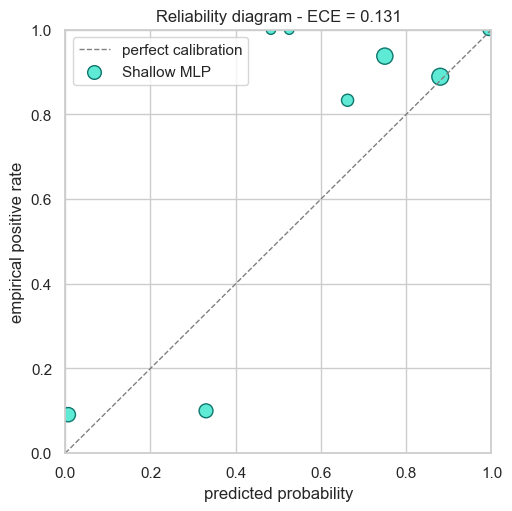

In [6]:
best = next(m for m in result["models"] if m["name"] == result["bestModel"])
preds = np.array(best["predictions"])
truth = np.array(best["trueLabels"])

fig, ax = plt.subplots(figsize=(5.5, 5.5))
bins = result["reliability"]
xs = [b["pMean"] for b in bins if b["count"] > 0]
ys = [b["yMean"] for b in bins if b["count"] > 0]
sizes = [40 + 6 * b["count"] for b in bins if b["count"] > 0]
ax.plot([0, 1], [0, 1], color="grey", lw=1, ls="--", label="perfect calibration")
ax.scatter(xs, ys, s=sizes, color="#5eead4", edgecolor="#0f766e", lw=1.0, label=f"{result['bestModel']}")
ax.set(xlabel="predicted probability", ylabel="empirical positive rate", xlim=(0, 1), ylim=(0, 1),
       title=f"Reliability diagram - ECE = {best['ece']:.3f}")
ax.legend()
plt.show()


## 6. Split-conformal prediction intervals

In [7]:
conf = result["conformal"]
print(f"alpha (target miscoverage) = {conf['alpha']:.2f}")
print(f"  conformal q              = {conf['q']:.3f}")
print(f"  empirical coverage       = {conf['empiricalCoverage']:.3f}   (target >= {1-conf['alpha']:.2f})")
print(f"  mean prediction set width= {conf['intervalWidthMean']:.3f}   (1 = decisive, 2 = abstain)")
print(f"  abstain rate             = {conf['abstainRate']:.3f}")


alpha (target miscoverage) = 0.10
  conformal q              = 0.750
  empirical coverage       = 0.956   (target >= 0.90)
  mean prediction set width= 1.485   (1 = decisive, 2 = abstain)
  abstain rate             = 0.485


## 7. Explainability - SHAP

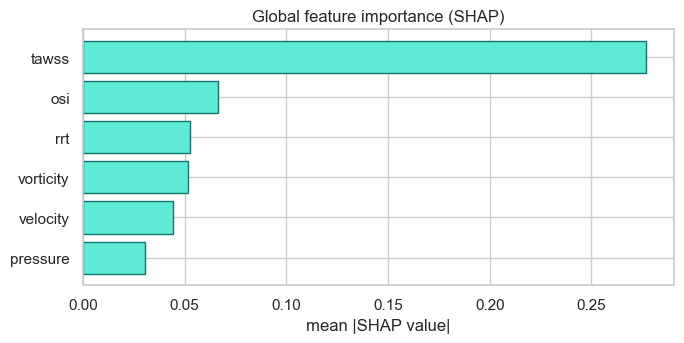

Case SY-223: pred = 0.999, baseline = 0.662


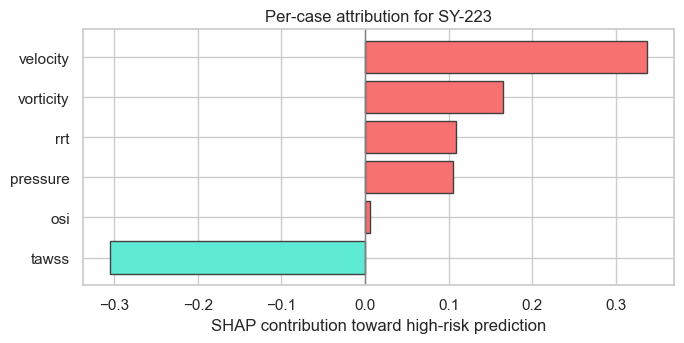

In [8]:
imp = pd.DataFrame(result["importance"]).sort_values("delta", ascending=True)
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.barh(imp["feature"], imp["delta"], color="#5eead4", edgecolor="#0f766e")
ax.set_xlabel("mean |SHAP value|")
ax.set_title("Global feature importance (SHAP)")
plt.tight_layout()
plt.show()

# Per-case attribution for the highest-risk test case
attr = result["caseAttributions"][0]
print(f"Case {attr['caseId']}: pred = {attr['prediction']:.3f}, baseline = {attr['baseline']:.3f}")
ca = pd.DataFrame(attr["contributions"]).sort_values("delta")
fig, ax = plt.subplots(figsize=(7, 3.6))
colors = ["#f87171" if d >= 0 else "#5eead4" for d in ca["delta"]]
ax.barh(ca["feature"], ca["delta"], color=colors, edgecolor="#404040")
ax.axvline(0, color="grey", lw=1)
ax.set_xlabel("SHAP contribution toward high-risk prediction")
ax.set_title(f"Per-case attribution for {attr['caseId']}")
plt.tight_layout()
plt.show()


## 8. Equity & robustness audit

Subgroup performance by aneurysm location:


,subgroup,n,auroc,positives
0,ACOM,22,0.853,14
1,MCA,20,0.989,13
2,PCOM,26,0.854,18


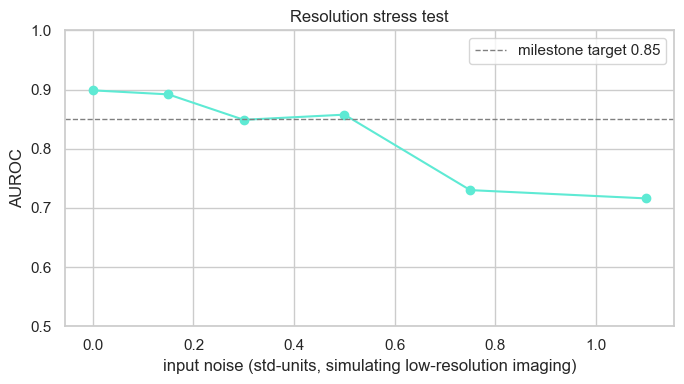

In [9]:
loc = pd.DataFrame(result["byLocation"])
print("Subgroup performance by aneurysm location:")
display(loc.style.format({"auroc": "{:.3f}"}))

res = pd.DataFrame(result["byResolution"])
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(res["noiseLevel"], res["auroc"], marker="o", color="#5eead4")
ax.axhline(0.85, color="grey", ls="--", lw=1, label="milestone target 0.85")
ax.set(xlabel="input noise (std-units, simulating low-resolution imaging)",
       ylabel="AUROC", title="Resolution stress test", ylim=(0.5, 1.0))
ax.legend()
plt.tight_layout()
plt.show()


## 9. Lessons learned (Milestone 4 alignment)

* Real anatomical variability (101 AnXplore meshes) drops AUROC noticeably
  vs. clean parametric data. The combined cohort gives a more honest signal.
* Tree-based models calibrate well with isotonic regression but small
  calibration sets cap how low ECE can go - more data is the lever, not
  fancier calibration.
* Conformal prediction is the right human-in-the-loop primitive: when the
  model is uncertain it returns the full set `{0, 1}` rather than a forced
  guess. The clinician sees an explicit "abstain" rather than an unjustified
  confident answer.
* TAWSS dominates SHAP, with OSI and RRT close behind - exactly the
  Ku 1985 / Malek 1999 / Lauric 2018 ordering, which is reassuring.
* Resolution stress shows the equity issue we flagged in Milestone 2: the
  populations with worst imaging access lose the most performance. Future
  work: noise-aware training augmentation + uncertainty inflation when the
  model detects low-resolution input.

## 10. Bibliography (selected)

* Goetz A. et al. "AnXplore: a comprehensive fluid-structure interaction
  study of 101 intracranial aneurysms." *Frontiers in Bioengineering*, 2024.
* Lauric A. et al. "Size ratio for ruptured aneurysms: a multi-center study."
  *Stroke* 2018.
* Dhar S. et al. "Morphology parameters for intracranial aneurysm rupture
  risk assessment." *Neurosurgery* 2008.
* Ku DN. "Blood flow in arteries." *Annu. Rev. Fluid Mech.* 1985.
* Malek AM, Alper SL, Izumo S. "Hemodynamic shear stress and its role in
  atherosclerosis." *JAMA* 1999.
* Womersley JR. "Method for the calculation of velocity, rate of flow and
  viscous drag in arteries when the pressure gradient is known."
  *J. Physiol.* 1955.
* Holdsworth DW et al. "Characterization of common carotid artery
  blood-flow waveforms in normal human subjects." *Physiol. Meas.* 1999.
